# Module 2 — Handling Text Data

Series: 
> Build a Large Language Model From the Inside Out Companion to blog post: [How Does an LLM Read "Abeg, My Transfer Never Enter"?](https://academy.confamnode.com/blog/how-does-an-llm-read-abeg-my-transfer)


## 2.1 Install packages

In [1]:
!pip install -q torch --index-url https://download.pytorch.org/whl/cpu 
!pip install -q tiktoken

Check packages' versions

In [2]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.14.0+cpu
tiktoken version: 0.14.0


Packages' versions used at the time of creating this notebook

- `torch` -> `2.14.0+cpu`
- `tiktoken` -> `0.14.0`

## 2.2 What are embeddings?

Deep neural network models including LLMs, cannot process raw text directly because neural networks perform mathematical operations on numbers. Text such as:
```text
- Lagos
- Transfer
- Doctor
- Network
```
is categorical/discrete data.

The neural network needs numerical representation, so we need:
```text
word/token -> number/vector
```
That's an **embedding**.

An **embedding** converts discrete data, such as a token, into a numerical vector that an LLM can work with. It maps an object to a point in a continuous vector space.

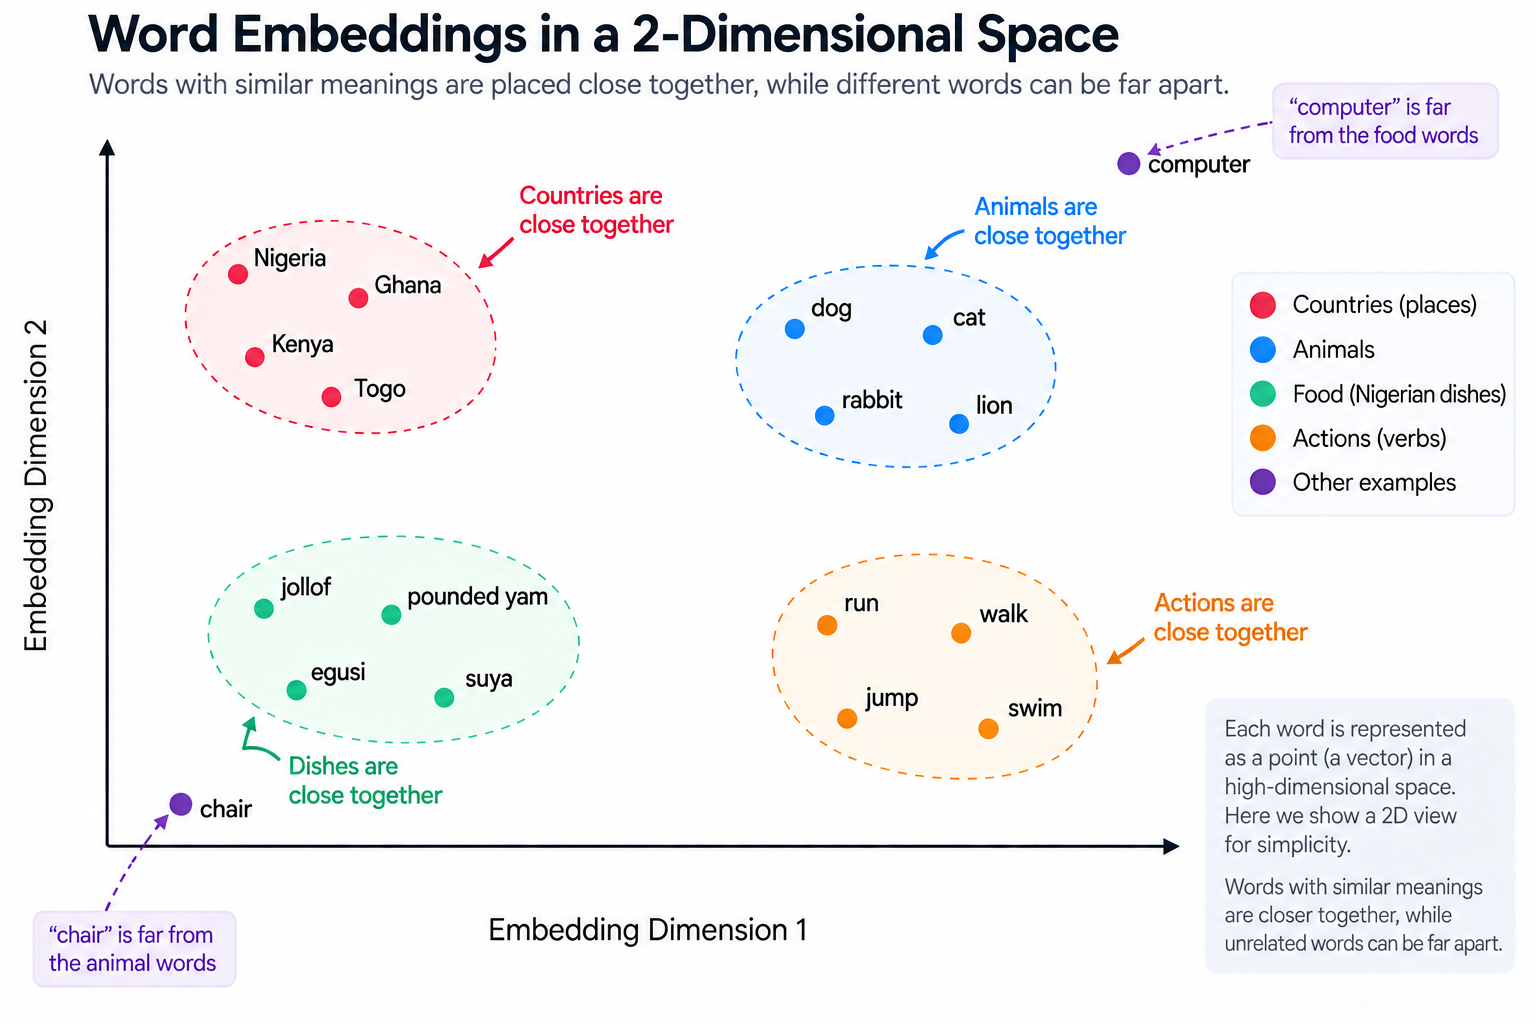

## 2.3 Tokenizing text

Tokenizing text is the preprocessing step we perform to create embeddings to be used by a large language model. Here we will take raw text and split it into smaller units called tokens. The tokens include individual words, and special characters such as punctuation marks.

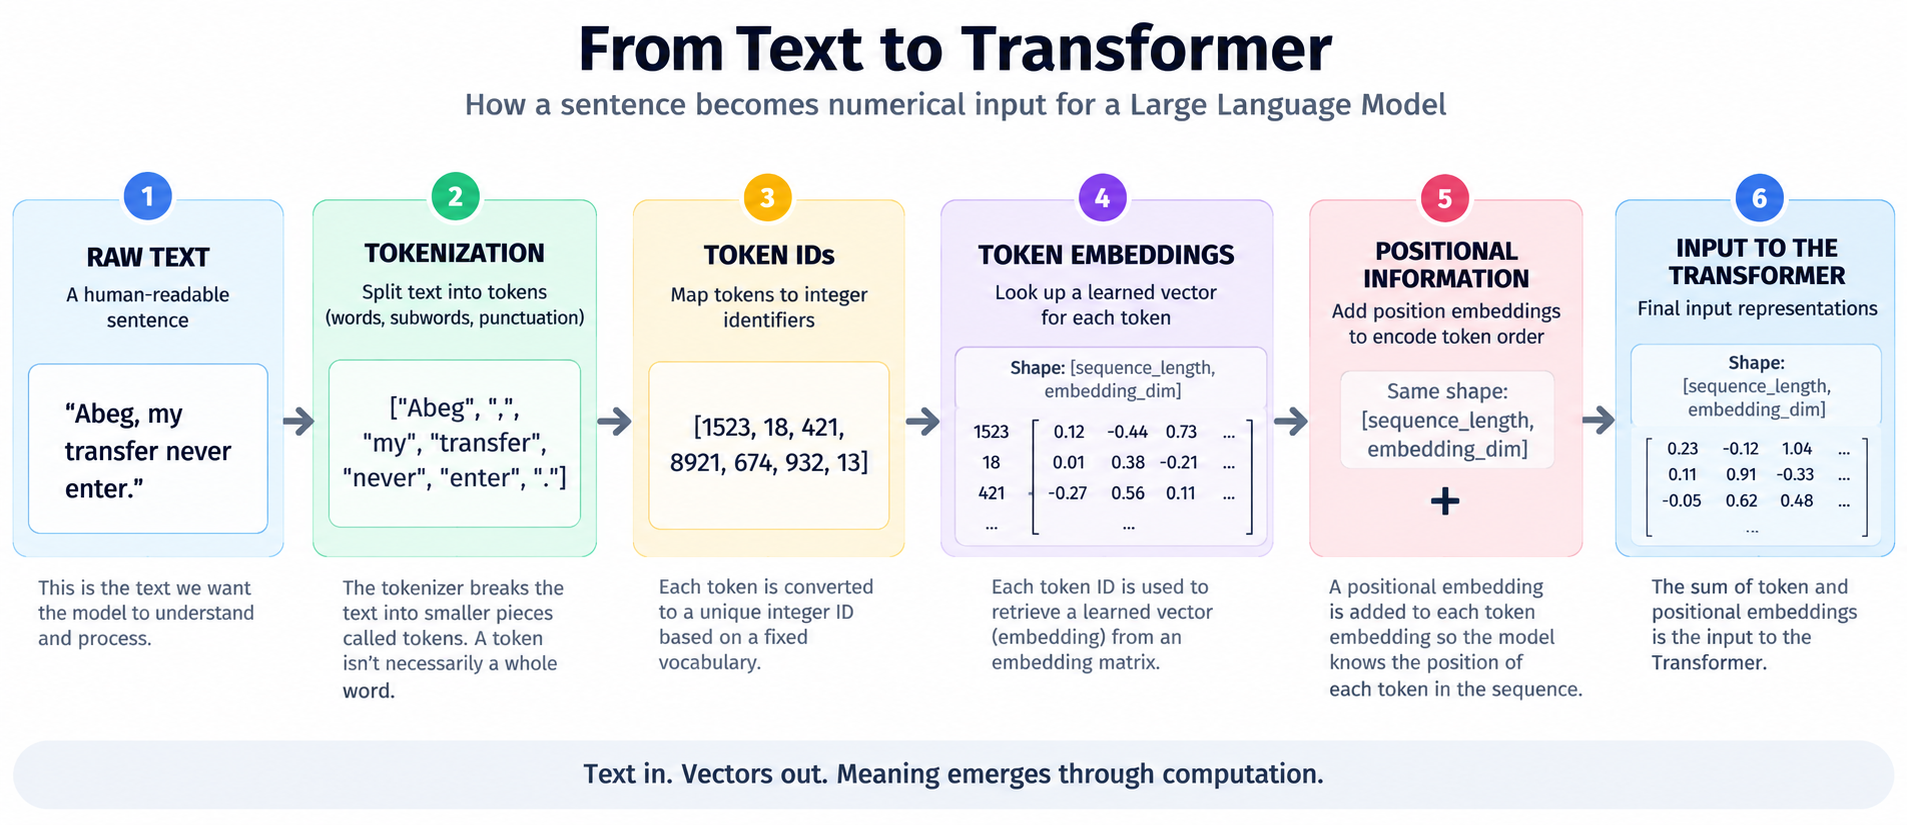

### Download the file

Source text: 
> **[The Tortoise with a Pretty Daughter](https://www.gutenberg.org/cache/epub/34655/pg34655-images.html#I)**

Story I from [Folk Stories from Southern Nigeria, West Africa by Elphinstone Dayrell](https://www.gutenberg.org/ebooks/34655). It is a public domain traditional folktale written in the early 20th century.

In [3]:
import os
import requests

url = "https://raw.githubusercontent.com/confamnode-academy/build-llm-from-the-inside-out/main/mod02/the-woman-with-two-skins.txt"
fp = "the-woman-with-two-skins.txt"

if not os.path.exists(fp):    
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(fp, "wb") as f:
        f.write(response.content)

### Load the file

In [4]:
with open(fp, "r", encoding="utf-8") as f:
  raw_text = f.read()
    
print(f"Total number of characters: {len(raw_text)}\n")
print(f"Raw text:\n{raw_text[:150]}")

Total number of characters: 13582

Raw text:
The Woman with Two Skins

Eyamba I. of Calabar was a very powerful king. He fought and conquered all the surrounding countries, killing all the old me


### Split the text

Let's use regular expression to split on whitespaces. Firstly, we will test it

In [5]:
import re

text = "Abeg, my transfer never enter. First, make we test am."
result = re.split(r'(\s)', text)
print(result)

['Abeg,', ' ', 'my', ' ', 'transfer', ' ', 'never', ' ', 'enter.', ' ', 'First,', ' ', 'make', ' ', 'we', ' ', 'test', ' ', 'am.']


We will now modify the regular expression to also split on special characters such as punctuation marks (periods and commas)

In [6]:
result = re.split(r'([,.]|\s)', text)
print(result)

['Abeg', ',', '', ' ', 'my', ' ', 'transfer', ' ', 'never', ' ', 'enter', '.', '', ' ', 'First', ',', '', ' ', 'make', ' ', 'we', ' ', 'test', ' ', 'am', '.', '']


Let's remove the empty strings

In [7]:
result = [
    item for item in result
    if item.strip() # Remove whitespace from string. Also check if item is a string or just whitespace. Filter out of it's just a whitespace
] 
print(result)

['Abeg', ',', 'my', 'transfer', 'never', 'enter', '.', 'First', ',', 'make', 'we', 'test', 'am', '.']


We need to handle other kinds of special characters (question mark, dash, parenthesis, etc.)

In [8]:
text = "Abeg, my transfer never enter. Na wa oh ! We still _ dey test am?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [
    item.strip() for item in result
    if item.strip() # Remove whitespace from string. Also check if item is a string or just whitespace. Filter out of it's just a whitespace
] 
print(result)

['Abeg', ',', 'my', 'transfer', 'never', 'enter', '.', 'Na', 'wa', 'oh', '!', 'We', 'still', '_', 'dey', 'test', 'am', '?']


Let's apply this tokenization to the raw text

In [9]:
raw_tokens = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
raw_tokens = [
    raw_token.strip() for raw_token in raw_tokens
    if raw_token.strip() # Remove whitespace from string. Also check if item is a string or just whitespace. Filter out of it's just a whitespace
]
print(f"Total number of tokens: {len(raw_tokens)}\n")
print(f"Raw tokens:\n{raw_tokens[:50]}")

Total number of tokens: 3034

Raw tokens:
['The', 'Woman', 'with', 'Two', 'Skins', 'Eyamba', 'I', '.', 'of', 'Calabar', 'was', 'a', 'very', 'powerful', 'king', '.', 'He', 'fought', 'and', 'conquered', 'all', 'the', 'surrounding', 'countries', ',', 'killing', 'all', 'the', 'old', 'men', 'and', 'women', ',', 'but', 'the', 'able-bodied', 'men', 'and', 'girls', 'he', 'caught', 'and', 'brought', 'back', 'as', 'slaves', ',', 'and', 'they', 'worked']


## 2.4 Convert tokens to token IDs

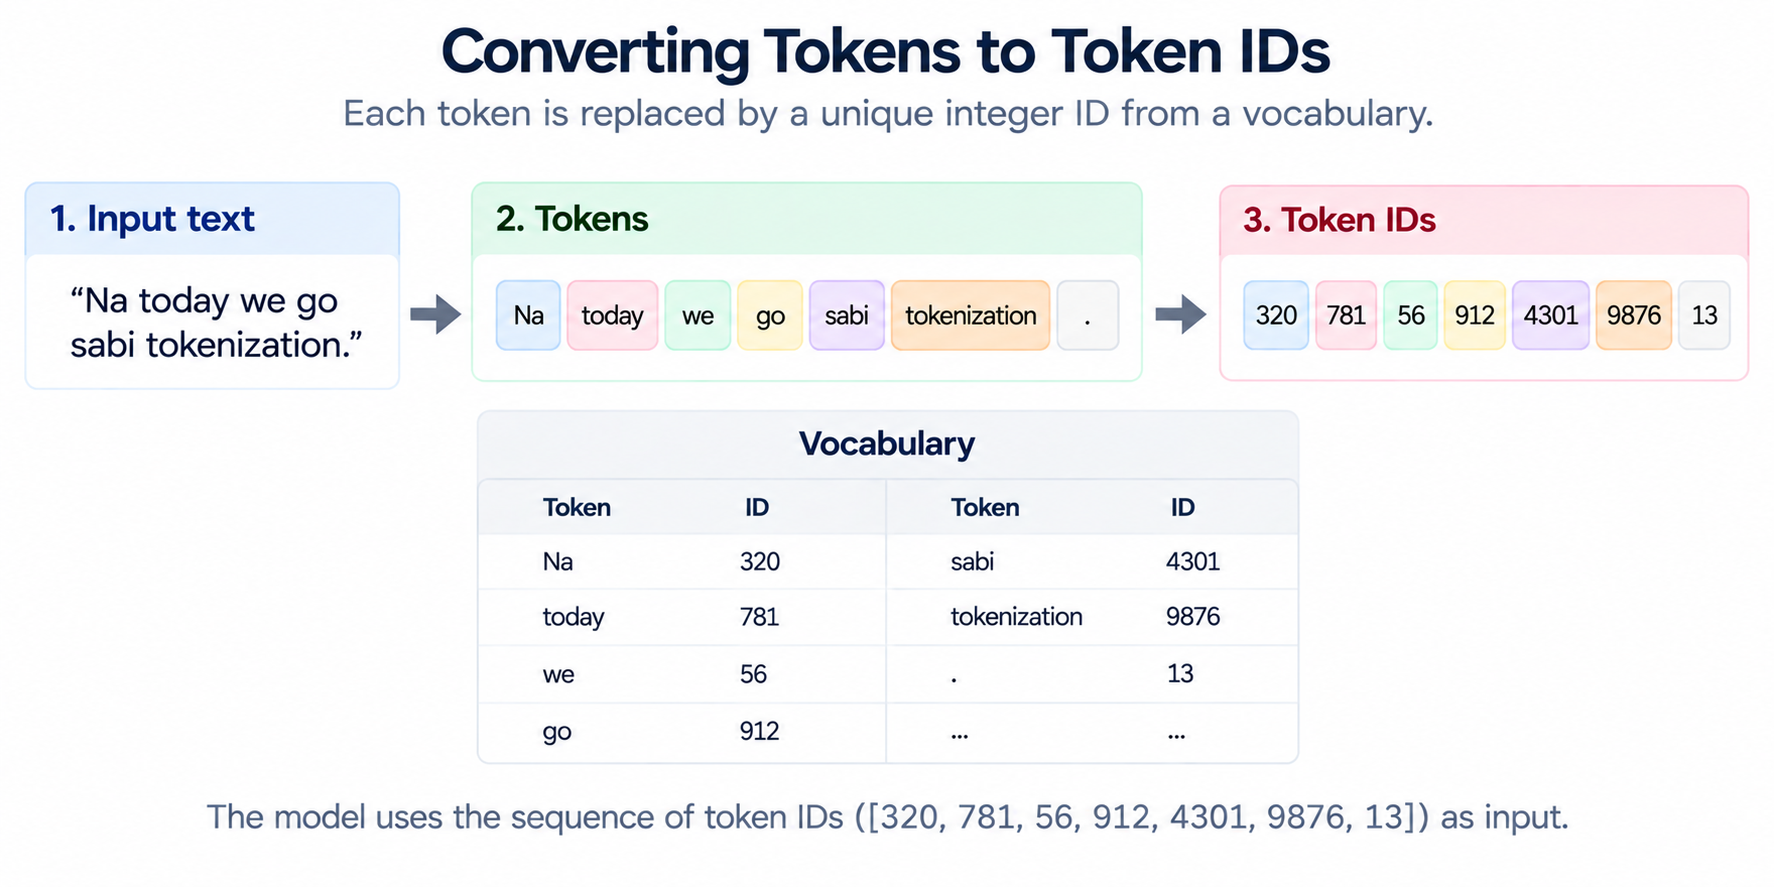

### Create a list of all unique tokens and sort them

We can use the tokens to build a vocabulary of unique tokens

In [10]:
unique_tokens = sorted(set(raw_tokens))
vocab_size = len(unique_tokens)
print(vocab_size)

594


### Create a vocabulary

In [11]:
vocab = {tok:idx for idx,tok in enumerate(unique_tokens)}
for i, pair in enumerate(vocab.items()):
    print(pair)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('Adiaha', 11)
('After', 12)
('All', 13)
('Am', 14)
('And', 15)
('As', 16)
('But', 17)
('Calabar', 18)
('Directly', 19)
('Egbo', 20)
('Egbos', 21)
('Every', 22)
('Eyamba', 23)
('For', 24)
('He', 25)
('Her', 26)
('His', 27)
('However', 28)
('I', 29)
('If', 30)
('Immediately', 31)
('In', 32)
('Is', 33)
('It', 34)
('Ju', 35)
('Now', 36)
('On', 37)
('One', 38)
('She', 39)
('Skins', 40)
('So', 41)
('That', 42)
('The', 43)
('Then', 44)
('They', 45)
('This', 46)
('To', 47)
('Two', 48)
('Water', 49)
('When', 50)


### Implementing a basic text tokenizer

In [12]:
class BasicTokenizerV1:
    def __init__(self, vocab):
        self.token_to_id = vocab # keep the vocab dict itself, used by encode()
        self.id_to_token = {idx:tok for tok, idx in vocab.items()} # flip it so decode() can go ID -> token

    def encode(self, text): # turn raw text to a list of token IDs
        raw_tokens = re.split(r'([,.?_!"()\']|--|\s)', text)
        raw_tokens = [
            tok.strip() for tok in raw_tokens if tok.strip()
        ]
        token_ids = [self.token_to_id[tok] for tok in raw_tokens]
        return token_ids
    
    def decode(self, token_ids):  # turn a list of token IDs back into readable text
        text = " ".join([self.id_to_token[tid] for tid in token_ids])
    
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)  # strip the stray space before punctuation
        return text

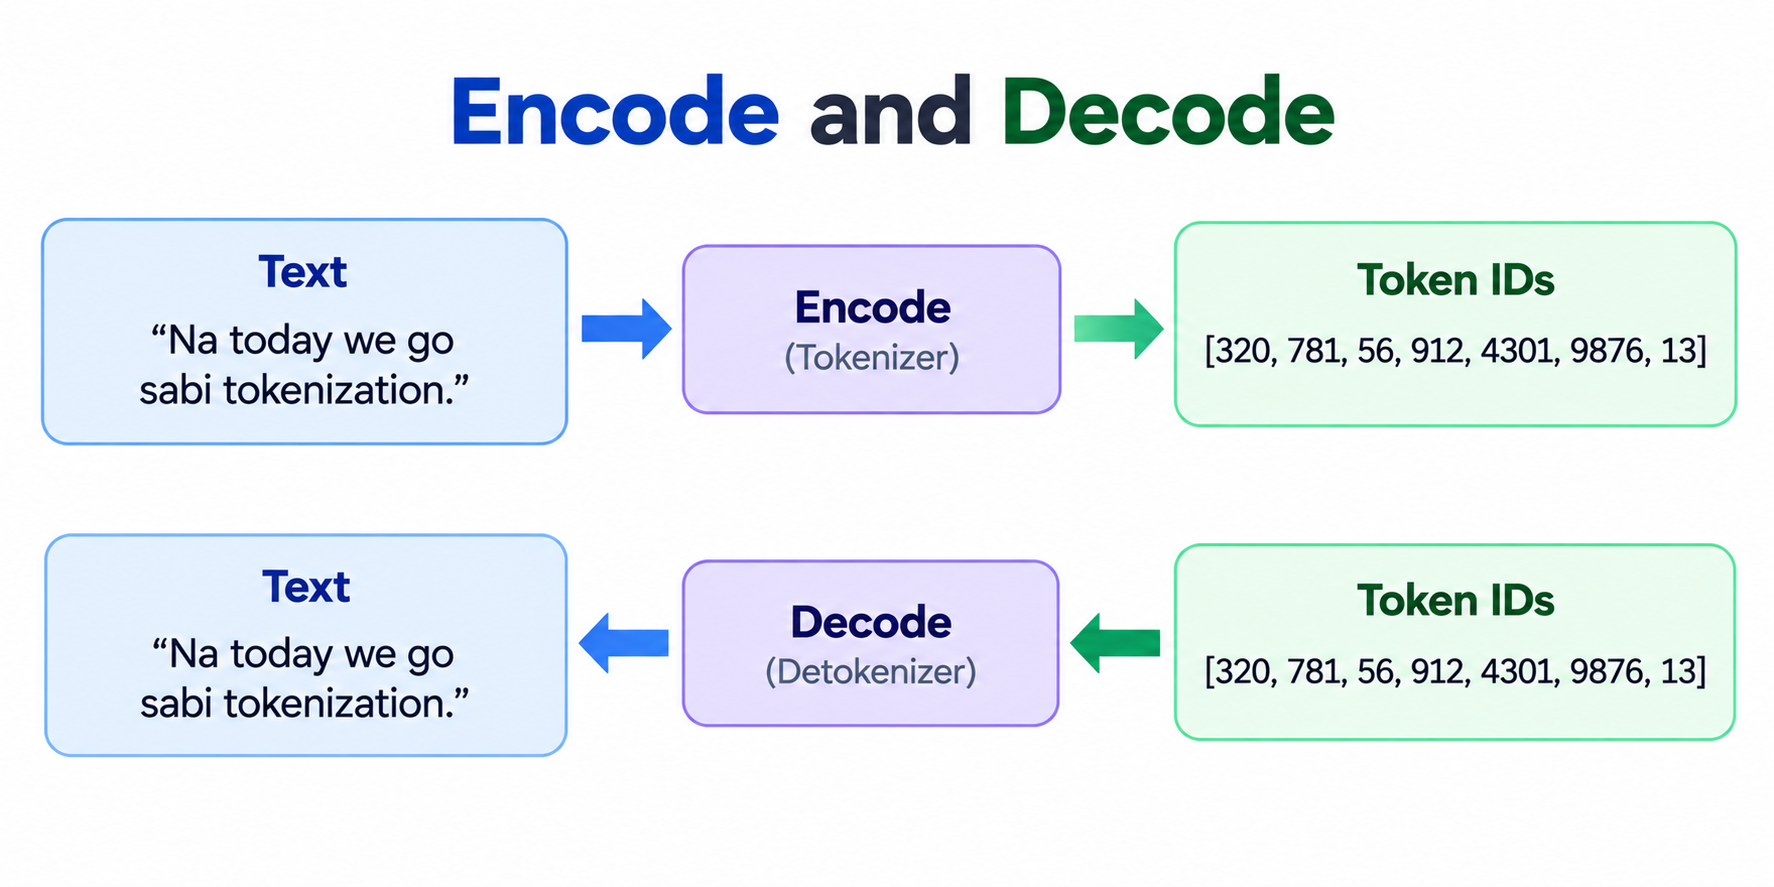

### Instantiate the `BasicTokenizerV1`

In [13]:
tokenizer = BasicTokenizerV1(vocab)
txt = """Then the head wife went again to the
        Ju Ju man and got more medicine, which made 
        the king forget Adiaha for three years, 
        during which time she was in mourning for her son."""
token_ids = tokenizer.encode(txt)
print(token_ids)

[44, 508, 264, 572, 561, 68, 528, 508, 35, 35, 335, 80, 247, 352, 344, 5, 567, 332, 508, 303, 226, 11, 224, 519, 591, 5, 191, 567, 526, 463, 553, 286, 357, 224, 269, 477, 7]


### Turn the token IDs back into text

In [14]:
print(tokenizer.decode(token_ids))

Then the head wife went again to the Ju Ju man and got more medicine, which made the king forget Adiaha for three years, during which time she was in mourning for her son.


## 2.5 Adding special context tokens

What if the LLM encounters a token that was not in our vocabulary? Let's try and see:

In [15]:
tokenizer = BasicTokenizerV1(vocab)
txt = "Wetin dey happen for your side?"
tokenizer.encode(txt)

KeyError: 'Wetin'

As you can see we encountered a `KeyError` as our vocabulary doesn't have the token "Wetin". In cases like this, we add a special tokens like `"<|unk|>"` to our vocabulary to indicate unknown tokens.

We can also add `"<|endoftext|>"`. GPT-2 uses this special token in training to tell the LLM that it is at the end of the text. It is also used to concatenate unrelated texts in datasets that are made of different documents, separate articles, etc.

These special tokens help the LLM understand the structure of text. There are other kinds of special tokens:
- `[BOS]` - beginning of sequence: Denotes the start of a sequence
- `[EOS]` - end of sequence: Denotes the end of a sequence. Good for concatenating multiple unrelated texts. Used to separate independent texts in the sequence (e.g. two different blog posts or two different lab reports, etc.). It is similar to `"<|endoftext|>"`
- `[PAD]` - padding: Used to make sure shorter texts in a batch are extended or "padded" up to the length of the length of the longest text.

In [16]:
unique_tokens = sorted(list(set(raw_tokens)))
unique_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {tok:idx for idx, tok in enumerate(unique_tokens)}

print(len(vocab.items()))

596


In [17]:
for i, pair in enumerate(list(vocab.items())[-5:]):
  print(pair)

('years', 591)
('you', 592)
('young', 593)
('<|endoftext|>', 594)
('<|unk|>', 595)


### Create a basic text tokenizer that handles unknown words

In [18]:
class BasicTokenizerV2:
    def __init__(self, vocab):
        self.token_to_id = vocab # keep the vocab dict itself, used by encode()
        self.id_to_token = {idx:tok for tok, idx in vocab.items()} # flip it so decode() can go ID -> token

    def encode(self, text): # turn raw text to a list of token IDs
        raw_tokens = re.split(r'([,.?_!"()\']|--|\s)', text)
        raw_tokens = [
            tok.strip() for tok in raw_tokens if tok.strip()
        ]
        raw_tokens = [
            tok if tok in self.token_to_id
            else "<|unk|>" for tok in raw_tokens # Use unknown word indicator (<|unk|>) if token does not exist in our vocabulary
        ]
        token_ids = [self.token_to_id[tok] for tok in raw_tokens]
        return token_ids
    
    def decode(self, token_ids):  # turn a list of token IDs back into readable text
        text = " ".join([self.id_to_token[tid] for tid in token_ids])
    
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)  # strip the stray space before punctuation
        return text

### Use `BasicTokenizerV2`

In [19]:
txt1 = "Wetin be the name of that place?"
txt2 = "I will like to order jollof."
txt = " <|endoftext|> ".join((txt1, txt2))
print(txt)

Wetin be the name of that place? <|endoftext|> I will like to order jollof.


Tokenize the sample text using the `BasicTokenizerV2` on the vocab

In [20]:
tokenizer = BasicTokenizerV2(vocab)
print(f"Encoded tokens:\n{tokenizer.encode(txt)}\n")
print(f"Decoded tokens:\n{tokenizer.decode(tokenizer.encode(txt))}")

Encoded tokens:
[595, 102, 508, 361, 373, 507, 403, 10, 594, 29, 573, 321, 528, 385, 595, 7]

Decoded tokens:
<|unk|> be the name of that place? <|endoftext|> I will like to order <|unk|>.
